In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, desc, lower, when, avg, min, max, log, month, dayofweek
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt

In [2]:
spark = (
    SparkSession.builder
    .appName("PriceElasticity")
    .master("local[*]")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/29 10:56:20 WARN Utils: Your hostname, Handes-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.61 instead (on interface en0)
26/06/29 10:56:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/29 10:56:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path = "./DatafinitiElectronicsProductsPricingData_with_category.csv"

df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("delimiter", ",")
    .csv(path)
)

In [4]:
df.show()
df.printSchema()

+-------+--------------------+--------------------+------+--------------------+---------+------+---------+--------------------+--------+--------------------+--------------------+--------------------+--------------------+------------+-------------+--------------------+-----------+
|Cluster|       Category_name|                name| price|            merchant|condition|isSale|    brand|       p_description|currency|           dateAdded|            dateSeen|         dateUpdated|           imageURLs|manufacturer|     shipping|          sourceURLs|     weight|
+-------+--------------------+--------------------+------+--------------------+---------+------+---------+--------------------+--------+--------------------+--------------------+--------------------+--------------------+------------+-------------+--------------------+-----------+
|     11|    mount, tv, stand|Sanus VLF410B1 10...|104.99|         Bestbuy.com|      New| False|    Sanus|Audio & Video Acc...|     USD|2015-04-13T12:00:51Z|

In [5]:
df.count()

14592

In [6]:
df.columns

['Cluster',
 'Category_name',
 'name',
 'price',
 'merchant',
 'condition',
 'isSale',
 'brand',
 'p_description',
 'currency',
 'dateAdded',
 'dateSeen',
 'dateUpdated',
 'imageURLs',
 'manufacturer',
 'shipping',
 'sourceURLs',
 'weight']

In [7]:
#Check for missings
missing = (
    df.select(
        [
            sum(col(c).isNull().cast('int')).alias(c) for c in df.columns
        ]
    )
)
missing.show()

+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+
|Cluster|Category_name|name|price|merchant|condition|isSale|brand|p_description|currency|dateAdded|dateSeen|dateUpdated|imageURLs|manufacturer|shipping|sourceURLs|weight|
+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+
|      0|            0|   0|    0|     772|     1403|     0|    0|            0|       0|        0|       0|          0|        0|        6972|    5799|         0|     0|
+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+



In [8]:
#Check duplicates
dups = (
    df
    .groupby(
        'Category_name', 'name', 'price', 'merchant', 'isSale', 'dateSeen'
    )
    .count()
    .filter(col('count')>1)
)
dups.show()

+--------------------+--------------------+-------+--------------------+------+--------------------+-----+
|       Category_name|                name|  price|            merchant|isSale|            dateSeen|count|
+--------------------+--------------------+-------+--------------------+------+--------------------+-----+
| tv, television, led|Samsung - 49 Clas...|1297.99|        Beach Camera|  True|2018-04-26T17:00:00Z|    3|
| tv, television, led|SunBriteTV - Sign...|2799.99|         Bestbuy.com| False|2017-08-01T03:00:...|    2|
| tv, television, led|MU8000-Series 65-...|2197.99|        Beach Camera|  True|2018-04-26T17:00:00Z|    2|
|memory, computer,...|CORSAIR - VENGEAN...| 129.99|         Bestbuy.com| False|2017-03-30T10:00:...|    2|
|  tv, 4k, television|LG Electronics OL...|4999.99|        Beach Camera|  True|2017-10-28T17:00:...|    2|
| tv, television, led|Details About Sam...| 1499.0|        Beach Camera|  True|2017-11-08T20:00:00Z|    2|
|  tv, 4k, television|LG - 65 Class -

In [9]:
#check distributions
df.describe(
    [
        'price',
        'isSale'
    ]
).show()

+-------+------------------+--------------------+
|summary|             price|              isSale|
+-------+------------------+--------------------+
|  count|             14592|               14592|
|   mean|509.57889734100473|                NULL|
| stddev|1008.5127379283456|                NULL|
|    min|               1.0| 2) New Kicker 41...|
|    max|           26871.0|                True|
+-------+------------------+--------------------+



In [10]:
#remove odd values for isSale
df.groupby('isSale').count().show()

+--------------------+-----+
|              isSale|count|
+--------------------+-----+
| Stereo Amp Power...|    2|
|               False|11088|
|                True| 3498|
| 3 ft. 8 GA Black...|    1|
| Item Weight: 8 lbs.|    1|
| 2) New Kicker 41...|    1|
| Frequency Respon...|    1|
+--------------------+-----+



In [11]:
df = df.filter(
    col('isSale').isin('True', 'False')
)

df.count()

14586

In [12]:
#select 1 product type
df.groupby(
    'Category_name'
).count().orderBy(desc("count")).show()

+--------------------+-----+
|       Category_name|count|
+--------------------+-----+
|drive, storage, hard|  892|
| tv, television, led|  832|
|    laptop, computer|  626|
|  tv, 4k, television|  605|
|      car, gps, dash|  604|
|camera, shoot, point|  525|
|tablet, computer,...|  518|
|  camera, mirrorless|  500|
|receiver, amplifi...|  473|
|headphone, earbud...|  468|
|           headphone|  436|
|laptop, computer,...|  411|
|car, speaker, sub...|  366|
|        player, ipod|  363|
|speaker, portable...|  335|
|      speaker, audio|  324|
|sound, speaker, home|  320|
|      case, computer|  316|
|   monitor, computer|  314|
|networking, modem...|  264|
+--------------------+-----+
only showing top 20 rows


In [13]:
df = df.filter(
    col('Category_name')=='drive, storage, hard'
)
df.count()

892

In [14]:
#Check for missings
missing = (
    df.select(
        [
            sum(col(c).isNull().cast('int')).alias(c) for c in df.columns
        ]
    )
)
missing.show()

+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+
|Cluster|Category_name|name|price|merchant|condition|isSale|brand|p_description|currency|dateAdded|dateSeen|dateUpdated|imageURLs|manufacturer|shipping|sourceURLs|weight|
+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+
|      0|            0|   0|    0|      18|       77|     0|    0|            0|       0|        0|       0|          0|        0|         552|     319|         0|     0|
+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+



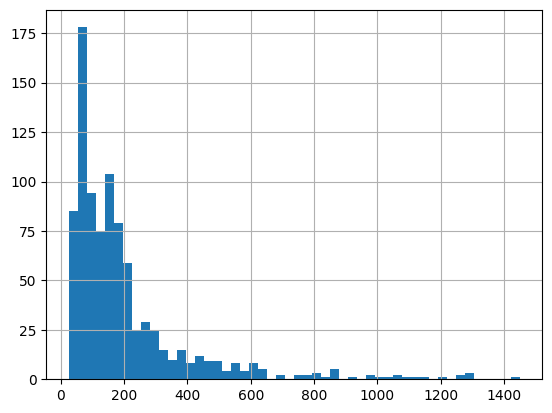

In [15]:
#histograms

pdf = df.select(
    'price',
    'isSale'
).toPandas()

pdf['price'].hist(bins=50)

plt.xlabel='price'
plt.ylabel='freq'
plt.show()

In [16]:
df = df.filter(
    col('price')<700
)
df.count()

862

In [17]:
df=df.withColumn(
    'isSale',
    when(lower(col('isSale')).isin("true", "1", "yes", "y"),1)
    .when(lower(col('isSale')).isin("false", "0", "no", "n"),0)
    .otherwise(None)
)

df=df.filter(col('isSale').isNotNull())

df=df.withColumn('isSale', col('isSale').cast('int'))

In [18]:
df.groupBy('merchant').agg(
    avg('price').alias('avg_price'),
    min('price').alias('min_price'),
    max('price').alias('max_price'),
    avg('isSale').alias('conversion_rate'),
).orderBy(desc('conversion_rate')).show(30)

+--------------------+------------------+---------+---------+-------------------+
|            merchant|         avg_price|min_price|max_price|    conversion_rate|
+--------------------+------------------+---------+---------+-------------------+
|             Spy Tec|            179.99|   179.99|   179.99|                1.0|
|           DealClock|            159.99|    99.99|   219.99|                1.0|
|        Beach Camera|             129.0|    129.0|    129.0|                1.0|
|          SaveTronix|             99.99|    99.99|    99.99|                1.0|
|      UnbeatableSale| 345.2271428571429|   175.98|    493.9| 0.7142857142857143|
|      memoryonly.com|146.24666666666667|   129.88|   169.98| 0.6666666666666666|
|          gamegear14|             34.19|    32.39|    35.99|                0.5|
|            OutletPC|119.25250000000001|    67.67|   220.99|                0.5|
|               DBSKY|             62.06|    44.13|    79.99|                0.5|
|DBSKYeasy-to-op

In [19]:
df = df.withColumn(
    'log_price',
    log(col('price'))
)

In [20]:
merchant_indexer = StringIndexer(
    inputCol='merchant',
    outputCol='merchant_idx',
    handleInvalid='skip'
)

df = merchant_indexer.fit(df).transform(df)

In [21]:
#time variable
df = df.withColumn(
    'month',
    month('dateSeen')
).withColumn(
    'day_of_week',
    dayofweek('dateSeen')
)

In [22]:
features = [
    'log_price',
    'merchant_idx',
    'month',
    'day_of_week'
]

In [23]:
assembler = VectorAssembler(
    inputCols=features,
    outputCol='features'
)

df_ml = assembler.transform(df)

In [24]:
#logistic regression
lr = LogisticRegression(
    featuresCol='features',
    labelCol='isSale'
)

model = lr.fit(df_ml)

26/06/29 10:56:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/06/29 10:56:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [25]:
model.coefficients

DenseVector([-0.2438, -0.0177, -0.0348, 0.1083])

In [26]:
beta = model.coefficients[0]
beta

np.float64(-0.2437570030984475)

In [27]:
pred = model.transform(df_ml)
pred.columns

['Cluster',
 'Category_name',
 'name',
 'price',
 'merchant',
 'condition',
 'isSale',
 'brand',
 'p_description',
 'currency',
 'dateAdded',
 'dateSeen',
 'dateUpdated',
 'imageURLs',
 'manufacturer',
 'shipping',
 'sourceURLs',
 'weight',
 'log_price',
 'merchant_idx',
 'month',
 'day_of_week',
 'features',
 'rawPrediction',
 'probability',
 'prediction']

In [28]:
pdff = pred.select(
    'features',
 'rawPrediction',
 'probability',
 'prediction'
).toPandas()

pdff

,features,rawPrediction,probability,prediction
0,"[5.416055956772293, 0.0, 5.0, 7.0]","[1.2240089376268952, -1.2240089376268952]","[0.7727682784016667, 0.22723172159833327]",0.0
1,"[5.521420917062225, 0.0, 5.0, 7.0]","[1.2496923845787564, -1.2496923845787564]","[0.7772466069304628, 0.22275339306953723]",0.0
2,"[4.499698553045857, 9.0, 12.0, 3.0]","[1.8369837931416475, -1.8369837931416475]","[0.8625915952906065, 0.13740840470939353]",0.0
3,"[4.59511985013459, 122.0, 7.0, 6.0]","[3.3622838410847966, -3.3622838410847966]","[0.9665047909697366, 0.03349520903026337]",0.0
4,"[4.430697744137536, 1.0, 5.0, 2.0]","[1.5431559933296894, -1.5431559933296894]","[0.8239230455171455, 0.17607695448285454]",0.0
...,...,...,...,...
839,"[4.18950321539533, 78.0, 3.0, 6.0]","[2.3449995095348433, -2.3449995095348433]","[0.9125359403736034, 0.08746405962639658]",0.0
840,"[4.204543354520176, 26.0, 7.0, 1.0]","[2.108686364032923, -2.108686364032923]","[0.8917445850838148, 0.10825541491618518]",0.0
841,"[4.174233411906258, 1.0, 12.0, 5.0]","[1.3993306018572211, -1.3993306018572211]","[0.8020776436955258, 0.1979223563044742]",0.0
842,"[4.077367938014984, 31.0, 3.0, 2.0]","[1.9186663622332638, -1.9186663622332638]","[0.8719896419280941, 0.12801035807190586]",0.0


In [29]:
probability_udf = udf(lambda v: float(v[1]), DoubleType())


pred = pred.withColumn(
    "p_sale",
    probability_udf(col("probability"))
)

In [30]:
pred = pred.withColumn(
    "elasticity",
    beta * (1 - col("p_sale"))
)

In [31]:
pred.select(
    avg("elasticity")
).show()

+--------------------+
|     avg(elasticity)|
+--------------------+
|-0.20245693988343047|
+--------------------+

